# Raman MIL pipeline check

Этот ноутбук нужен для быстрой поэтапной проверки, что weakly supervised PyTorch pipeline для Raman maps работает на реальных данных из проекта.

Что проверяем:
- окружение и импорты;
- совместимость с форматом данных из `notebooks/model.ipynb`;
- корректную сборку bag-level датасета;
- `forward` для `RamanMILModel`;
- короткий smoke-train на одном LOGO fold;
- map-level и spectrum-level inference;
- attribution по спектральной оси.

Ноутбук не пытается обучить финальную модель до максимального качества. Его задача: убедиться, что пайплайн запускается end-to-end без заглушек.

## 1. Рекомендуемый запуск

Если ты используешь `uv`, запускать Jupyter лучше из того же окружения:

```bash
uv sync
uv run jupyter lab
```

Важно: в текущем окружении были замечены конфликты OpenMP/MKL, если импортировать `numpy/scipy` раньше `torch`. Поэтому в первых ячейках этого ноутбука переменные окружения и порядок импортов выставлены специально.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("KMP_INIT_AT_FORK", "FALSE")
os.environ.setdefault("KMP_USE_SHM", "0")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "raman_mil_notebook_check"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR exists:", DATA_DIR.exists())
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)

PROJECT_ROOT: /home/yaroslav/progs/biohack/deeppick_mephi_2026/ml
DATA_DIR exists: True
ARTIFACTS_DIR: /home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/artifacts/raman_mil_notebook_check


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('/home/yaroslav/progs/biohack/deeppick_mephi_2026/ml')

from src.raman_mil.data import (
    build_dataset_for_center,
    build_map_records,
    dataframe_from_records,
    id2target,
    id2tissue,
    make_bag_collate,
)
from src.raman_mil.model import RamanMILConfig, RamanMILModel
from src.raman_mil.inference import predict_map, predict_spectrum, explain_spectrum, load_checkpoint
from src.raman_mil.training import TrainingConfig, run_logo_training

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## 2. Проверка структуры данных

Ниже мы воспроизводим сборку датасета так же, как это делает baseline-ноутбук:
- `center=1500`;
- `preprocess_mode='clean'`;
- общий `common_nu`;
- разворот карт в набор спектров.

Если здесь всё выглядит разумно, значит data contract не сломан.

In [3]:
ds = build_dataset_for_center(
    data_dir=DATA_DIR,
    center_value=1500,
    use_side=False,
    preprocess_mode="clean",
)

print("center:", ds["center"])
print("X_num:", ds["X_num"].shape)
print("X_cat:", ds["X_cat"].shape)
print("y:", ds["y"].shape)
print("groups:", ds["groups"].shape)
print("sample_ids:", ds["sample_ids"].shape)
print("common_nu length:", len(ds["common_nu"]))
print("common_nu range:", float(ds["common_nu"][0]), float(ds["common_nu"][-1]))
display(ds["meta_df"].head())

center=1500: 100%|██████████| 118/118 [05:30<00:00,  2.80s/it]

center: 1500
X_num: (61950, 1015)
X_cat: (61950, 1)
y: (61950,)
groups: (61950,)
sample_ids: (61950,)
common_nu length: 1015
common_nu range: 926.8291015625 2002.47119140625


,sample_id,path,name,n_spectra,shape_after,target,group,tissue,side,center,nu_min_original,nu_max_original
0,0,/home/yaroslav/progs/biohack/deeppick_mephi_20...,cortex_control_1group_633nm_center1500_obj100_...,525,"(35, 15, 1015)",control,1,cortex,none,1500,926.754883,2002.417969
1,1,/home/yaroslav/progs/biohack/deeppick_mephi_20...,cortex_control_1group_633nm_center1500_obj100_...,525,"(35, 15, 1015)",control,1,cortex,none,1500,926.754883,2002.417969
2,2,/home/yaroslav/progs/biohack/deeppick_mephi_20...,cortex_control_1group_633nm_center1500_obj100_...,525,"(35, 15, 1015)",control,1,cortex,none,1500,926.754883,2002.417969
3,3,/home/yaroslav/progs/biohack/deeppick_mephi_20...,cortex_control_1group_633nm_center1500_obj100_...,525,"(35, 15, 1015)",control,1,cortex,none,1500,926.754883,2002.417969
4,4,/home/yaroslav/progs/biohack/deeppick_mephi_20...,cortex_control_1group_633nm_center1500_obj100_...,525,"(35, 15, 1015)",control,1,cortex,none,1500,926.754883,2002.417969


In [6]:
records = build_map_records(ds)
records_df = dataframe_from_records(records)

print("n maps:", len(records))
print("unique groups:", sorted(records_df["group_name"].unique().tolist()))
print("class counts:")
display(records_df["label_name"].value_counts().sort_index())
print("group x target:")
display(pd.crosstab(records_df["group_name"], records_df["label_name"]))
print("tissue x target:")
display(pd.crosstab(records_df["tissue_name"], records_df["label_name"]))

n maps: 118
unique groups: ['1', '2a', '2b', '3']
class counts:


label_name
control    40
endo       36
exo        42
Name: count, dtype: int64

group x target:


label_name,control,endo,exo
group_name,,,
1,6,6,6
2a,12,12,12
2b,12,12,12
3,10,6,12


tissue x target:


label_name,control,endo,exo
tissue_name,,,
cerebellum,10,6,12
cortex,18,18,18
striatum,12,12,12


sample_id: 0
name: cortex_control_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place4_1.txt
target: control
tissue: cortex
spectra shape: (525, 1015)


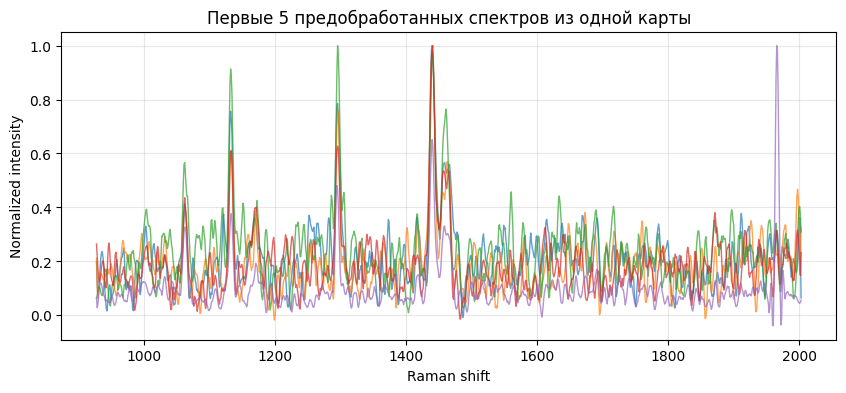

In [7]:
first_map = records[0]
print("sample_id:", first_map["sample_id"])
print("name:", first_map["name"])
print("target:", id2target[first_map["label"]])
print("tissue:", id2tissue[first_map["tissue_id"]])
print("spectra shape:", first_map["spectra"].shape)

plt.figure(figsize=(10, 4))
for idx in range(5):
    plt.plot(ds["common_nu"], first_map["spectra"][idx], alpha=0.7, linewidth=1)
plt.title("Первые 5 предобработанных спектров из одной карты")
plt.xlabel("Raman shift")
plt.ylabel("Normalized intensity")
plt.grid(alpha=0.3)
plt.show()

## 3. Проверка collate и bag representation

Эта ячейка показывает, что карты корректно упаковываются в батч переменной длины:
- `spectra`: `[B, N_max, L]`
- `mask`: `[B, N_max]`
- `lengths`: реальные числа спектров в картах после sampling/padding.

In [8]:
batch = make_bag_collate(max_spectra_per_map=64, random_sample=False)([
    {
        "spectra": torch.from_numpy(records[0]["spectra"]),
        "label": records[0]["label"],
        "group": records[0]["group"],
        "sample_id": records[0]["sample_id"],
        "tissue_id": records[0]["tissue_id"],
        "name": records[0]["name"],
    },
    {
        "spectra": torch.from_numpy(records[1]["spectra"]),
        "label": records[1]["label"],
        "group": records[1]["group"],
        "sample_id": records[1]["sample_id"],
        "tissue_id": records[1]["tissue_id"],
        "name": records[1]["name"],
    },
])

print("spectra batch shape:", tuple(batch.spectra.shape))
print("mask shape:", tuple(batch.mask.shape))
print("labels:", batch.labels.tolist())
print("lengths:", batch.lengths.tolist())
print("mask sums:", batch.mask.sum(dim=1).tolist())

spectra batch shape: (2, 64, 1015)
mask shape: (2, 64)
labels: [0, 0]
lengths: [64, 64]
mask sums: [64, 64]


## 4. Проверка `RamanMILModel` forward

Здесь проверяем базовый контракт модели:
- `forward_bag` возвращает bag logits;
- attention корректно нормируется по спектрам карты;
- инстансные logits имеют форму `[B, N, C]`.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RamanMILModel(
    RamanMILConfig(
        input_length=len(ds["common_nu"]),
        use_metadata=True,
        encoder_dim=128,
    )
).to(device)
model.eval()

with torch.no_grad():
    out = model.forward_bag(
        batch.spectra.to(device),
        batch.mask.to(device),
        batch.tissue_ids.to(device),
    )

print("bag_logits:", tuple(out["bag_logits"].shape))
print("bag_probs:", tuple(out["bag_probs"].shape))
print("instance_logits:", tuple(out["instance_logits"].shape))
print("attention:", tuple(out["attention"].shape))
print("attention sum for bag 0:", float(out["attention"][0, : batch.lengths[0]].sum().cpu()))
print("attention sum for bag 1:", float(out["attention"][1, : batch.lengths[1]].sum().cpu()))

bag_logits: (2, 3)
bag_probs: (2, 3)
instance_logits: (2, 64, 3)
attention: (2, 64)
attention sum for bag 0: 1.0
attention sum for bag 1: 1.0


## 5. Проверка single-spectrum и map inference на необученной модели

На этом этапе предсказания ещё случайные, но сам inference API должен работать без ошибок.

In [10]:
single_spec_result = predict_spectrum(
    model=model,
    spectrum=first_map["spectra"][0],
    tissue_id=first_map["tissue_id"],
    device=device,
)

map_result = predict_map(
    model=model,
    spectra=first_map["spectra"],
    tissue_id=first_map["tissue_id"],
    device=device,
    chunk_size=128,
)

print("single spectrum probs:", np.round(single_spec_result["probs"], 4))
print("single spectrum pred:", id2target[single_spec_result["pred_class"]])
print("map probs:", np.round(map_result["bag_probs"], 4))
print("map pred:", id2target[map_result["pred_class"]])
print("attention length:", len(map_result["attention"]))

single spectrum probs: [0.3785 0.3066 0.3149]
single spectrum pred: control
map probs: [0.4038 0.2947 0.3015]
map pred: control
attention length: 525


## 6. Короткий smoke-train

Ниже запускается минимальная end-to-end проверка обучения:
- только 1 LOGO fold;
- 1 epoch warmup;
- 1 epoch joint training.

Эта проверка нужна не для качества, а для ответа на вопрос: _"весь pipeline обучения, валидации, сохранения и инференса вообще проходит?"_

In [13]:
smoke_output_dir = ARTIFACTS_DIR / "smoke_train"

In [ ]:
smoke_config = TrainingConfig(
    data_dir=str(DATA_DIR),
    output_dir=str(smoke_output_dir),
    center=1500,
    preprocess_mode="clean",
    use_metadata=True,
    max_spectra_per_map=128,
    eval_chunk_size=128,
    batch_size=4,
    warmup_epochs=1,
    joint_epochs=1,
    fold_limit=1,
    device=str(device),
)

summary = run_logo_training(smoke_config)
summary

center=1500:   0%|          | 0/118 [00:00<?, ?it/s]/home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/.venv/lib/python3.11/site-packages/scipy/sparse/_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)
/home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/src/raman_mil/data.py:89: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(system, weights * y)
fold 0 joint: 100%|████████

{'macro_f1': 0.16666666666666666,
 'accuracy': 0.3333333333333333,
 'confusion_matrix': [[6, 0, 0], [6, 0, 0], [6, 0, 0]],
 'fold_metrics': [{'fold': 0,
   'macro_f1': 0.16666666666666666,
   'accuracy': 0.3333333333333333,
   'spectrum_macro_f1': 0.16666666666666666,
   'spectrum_accuracy': 0.3333333333333333,
   'confusion_matrix': [[6, 0, 0], [6, 0, 0], [6, 0, 0]],
   'classification_report': {'control': {'precision': 0.3333333333333333,
     'recall': 1.0,
     'f1-score': 0.5,
     'support': 6.0},
    'exo': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0},
    'endo': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0},
    'accuracy': 0.3333333333333333,
    'macro avg': {'precision': 0.1111111111111111,
     'recall': 0.3333333333333333,
     'f1-score': 0.16666666666666666,
     'support': 18.0},
    'weighted avg': {'precision': 0.1111111111111111,
     'recall': 0.3333333333333333,
     'f1-score': 0.16666666666666666,
     'support': 18.0}}

In [14]:
summary_path = smoke_output_dir / "summary.json"
oof_path = smoke_output_dir / "oof_predictions.csv"
fold_model_path = smoke_output_dir / "fold_0" / "best_model.pt"

print("summary exists:", summary_path.exists())
print("oof exists:", oof_path.exists())
print("checkpoint exists:", fold_model_path.exists())

oof_df = pd.read_csv(oof_path)
display(oof_df.head())

summary exists: True
oof exists: True
checkpoint exists: True


,sample_id,name,group,y_true,y_pred,n_spectra,p0,p1,p2,fold
0,0,cortex_control_1group_633nm_center1500_obj100_...,0,0,0,525,0.344722,0.335493,0.319785,0
1,1,cortex_control_1group_633nm_center1500_obj100_...,0,0,0,525,0.344055,0.334832,0.321112,0
2,2,cortex_control_1group_633nm_center1500_obj100_...,0,0,0,525,0.347060,0.333426,0.319514,0
3,3,cortex_control_1group_633nm_center1500_obj100_...,0,0,0,525,0.346445,0.333783,0.319772,0
4,4,cortex_control_1group_633nm_center1500_obj100_...,0,0,0,525,0.345603,0.335918,0.318479,0


## 7. Загрузка чекпоинта и повторный inference

Теперь проверяем уже обученный чекпоинт. Если всё корректно, значит:
- сериализация модели работает;
- `common_nu` и конфиг сохранены;
- inference API можно использовать независимо от train loop.

In [15]:
trained_model, checkpoint = load_checkpoint(fold_model_path, map_location=device)
trained_model = trained_model.to(device)

print("saved common_nu len:", len(checkpoint["common_nu"]))
print("saved preprocess mode:", checkpoint["preprocess_mode"])
print("use_metadata:", checkpoint["use_metadata"])
print("model config:")
display(checkpoint["model_config"])

saved common_nu len: 1015
saved preprocess mode: clean
use_metadata: True
model config:


{'input_length': 1015,
 'num_classes': 3,
 'encoder_dim': 128,
 'stem_channels': 32,
 'branch_channels': 32,
 'metadata_vocab_size': 3,
 'metadata_dim': 8,
 'use_metadata': True,
 'dropout': 0.15,
 'attention_dim': 128}

In [16]:
trained_map_result = predict_map(
    model=trained_model,
    spectra=first_map["spectra"],
    tissue_id=first_map["tissue_id"],
    device=device,
    chunk_size=128,
)

trained_spec_result = predict_spectrum(
    model=trained_model,
    spectrum=first_map["spectra"][0],
    tissue_id=first_map["tissue_id"],
    device=device,
)

print("true label:", id2target[first_map["label"]])
print("trained map pred:", id2target[trained_map_result["pred_class"]])
print("trained map probs:", np.round(trained_map_result["bag_probs"], 4))
print("trained spectrum pred:", id2target[trained_spec_result["pred_class"]])
print("trained spectrum probs:", np.round(trained_spec_result["probs"], 4))

true label: control
trained map pred: control
trained map probs: [0.3447 0.3355 0.3198]
trained spectrum pred: control
trained spectrum probs: [0.3643 0.3324 0.3033]


## 8. Проверка attribution

Для интерпретации берём наиболее важный по attention спектр из карты и считаем Integrated Gradients.

Ниже должны появиться:
- вектор важностей длины `L`;
- список наиболее важных спектральных интервалов;
- график спектра и attribution по частотам.

In [18]:
top_spec_idx = int(np.argmax(trained_map_result["attention"]))
top_spec = first_map["spectra"][top_spec_idx]

explanation = explain_spectrum(
    model=trained_model,
    spectrum=top_spec,
    common_nu=checkpoint["common_nu"],
    tissue_id=first_map["tissue_id"],
    target_class=trained_map_result["pred_class"],
    steps=64,
    device=device,
)

print("top spectrum index:", top_spec_idx)
print("target class:", explanation["target_name"])
display(pd.DataFrame(explanation["intervals"]))

top spectrum index: 256
target class: control


,start_idx,end_idx,start_nu,end_nu,peak_idx,peak_nu,score_sum,score_max
0,821,847,1797.738525,1825.319092,837,1814.711182,0.112379,0.036212
1,479,487,1434.947998,1443.434326,481,1437.069580,0.001202,0.000260
2,0,9,926.829102,936.376221,5,932.133057,0.001156,0.000251
3,1001,1008,1988.680908,1996.106445,1002,1989.741699,0.000739,0.000229
4,809,815,1785.009033,1791.373779,813,1789.252197,0.000269,0.000065


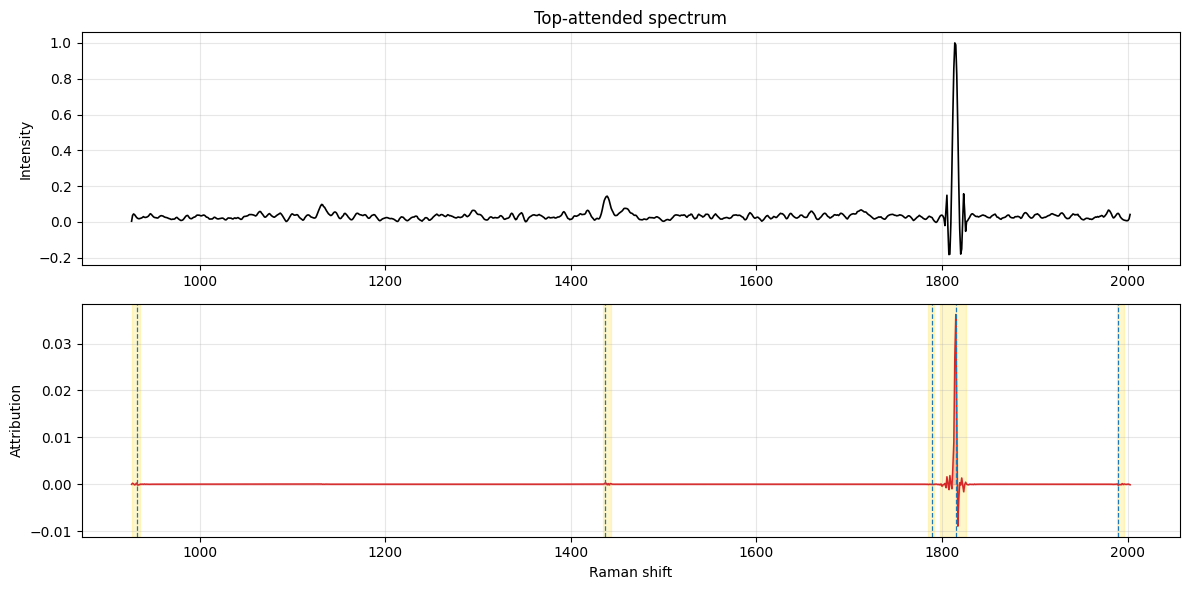

In [19]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(checkpoint["common_nu"], explanation["spectrum"], color="black", linewidth=1.2)
plt.title("Top-attended spectrum")
plt.ylabel("Intensity")
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(checkpoint["common_nu"], explanation["attribution"], color="tab:red", linewidth=1.1)
plt.fill_between(checkpoint["common_nu"], 0, explanation["attribution"], color="tab:red", alpha=0.25)
for interval in explanation["intervals"]:
    plt.axvspan(interval["start_nu"], interval["end_nu"], color="gold", alpha=0.2)
    plt.axvline(interval["peak_nu"], color="tab:blue", linestyle="--", linewidth=0.9)
plt.xlabel("Raman shift")
plt.ylabel("Attribution")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Как интерпретировать результат проверки

Можно считать, что всё в порядке, если:
- датасет собрался без ошибок и `common_nu` имеет разумную длину;
- `records` содержат карты, а не отдельные спектры;
- `forward_bag` отрабатывает и attention суммируется к 1;
- smoke-train завершился и сохранил `summary.json`, `oof_predictions.csv`, `best_model.pt`;
- чекпоинт загружается обратно;
- `predict_map`, `predict_spectrum`, `explain_spectrum` отрабатывают на реальных данных.

Если что-то ломается, обычно достаточно посмотреть, на каком именно разделе ноутбука произошла ошибка:
- раздел 2: проблема данных/предобработки;
- раздел 4: проблема модели/тензорных форм;
- раздел 6: проблема train loop или сохранения артефактов;
- раздел 8: проблема gradient-based attribution.